In [1]:
import os
import torch

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("Device name:", torch.cuda.get_device_name(0))

torch.cuda.empty_cache()
print("GPU memory cleared")

torch.manual_seed(42)
print("Seed set successfully")

CUDA available: True
Device count: 1
Device name: Tesla T4
GPU memory cleared
Seed set successfully


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install albumentations
!pip install tifffile

In [6]:
import os
import zipfile
import urllib.request

In [7]:
import os
import zipfile

# Path to your zip file in Drive
zip_path = '/content/drive/My Drive/trashcan.zip'
extract_path = '/content/trashcan'

# Unzip the file
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/trashcan')
    print("Dataset unzipped to /content/trashcan")
else:
    print("Dataset already unzipped")

# Set dataset path
dataset_path = '/content/trashcan'

Dataset unzipped to /content/trashcan


In [13]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import cv2
import time
import os
from torchvision.models.segmentation import deeplabv3_resnet50
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR
import json

os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

try:
    torch.cuda.empty_cache()
    print("GPU memory cleared successfully")
except RuntimeError as e:
    print(f"Error clearing GPU memory: {e}")
    print("Proceeding without clearing GPU memory...")

try:
    torch.manual_seed(42)
    print("Random seed set successfully")
except RuntimeError as e:
    print(f"Error setting random seed: {e}")
    print("Proceeding without setting random seed...")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

FIGURES_DIR = "/content/drive/My Drive/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

def time_since(start):
    return time.time() - start

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6, class_weights=None):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
        self.class_weights = class_weights if class_weights is not None else torch.ones(2)

    def forward(self, inputs, targets):
        inputs = torch.softmax(inputs, dim=1)
        targets = F.one_hot(targets, num_classes=2).permute(0, 3, 1, 2).float()
        intersection = (inputs * targets).sum(dim=(2, 3))
        union = inputs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        dice = dice * self.class_weights.to(inputs.device)
        dice = torch.clamp(dice, 0, 1)
        loss = 1 - dice.mean()
        return loss

class TrashCanDataset(Dataset):
    def __init__(self, base_dir, annotation_file, split='train', transform=None, target_size=128):
        self.base_dir = base_dir
        self.split = split
        self.data_dir = os.path.join(base_dir, split)
        self.target_size = target_size
        self.transform = transform
        if not os.path.exists(annotation_file):
            raise FileNotFoundError(f"Annotation file not found: {annotation_file}")

        if not os.path.exists(self.data_dir):
            raise FileNotFoundError(f"Data directory not found: {self.data_dir}")

        with open(annotation_file, 'r') as f:
            self.annotations = json.load(f)

        self.images = []
        self.image_ids = []
        for img_info in self.annotations['images']:
            self.images.append(img_info['file_name'])
            self.image_ids.append(img_info['id'])

        self.annots = {}
        for ann in self.annotations['annotations']:
            img_id = ann['image_id']
            if img_id not in self.annots:
                self.annots[img_id] = []
            self.annots[img_id].append(ann)

        self.valid_indices = []
        for idx in range(len(self.images)):
            img_path = os.path.join(self.data_dir, self.images[idx])
            if os.path.exists(img_path):
                self.valid_indices.append(idx)
            else:
                print(f"Image not found, skipping: {img_path}")

        print(f"Total images: {len(self.images)}, Valid images: {len(self.valid_indices)}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        idx = self.valid_indices[idx]
        img_name = self.images[idx]
        img_id = self.image_ids[idx]
        img_path = os.path.join(self.data_dir, img_name)

        img = cv2.imread(img_path)
        if img is None:
            print(f"Failed to load image {img_path}, skipping...")
            return self.__getitem__((idx + 1) % len(self.valid_indices))

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype(np.float32) / 255.0

        mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)
        if img_id in self.annots:
            for ann in self.annots[img_id]:
                seg = ann['segmentation']
                if isinstance(seg, list):
                    for contour in seg:
                        contour = np.array(contour).reshape(-1, 2).astype(np.int32)
                        cv2.fillPoly(mask, [contour], 1)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask'].long()

        expected_img_shape = (3, self.target_size, self.target_size)
        expected_mask_shape = (self.target_size, self.target_size)
        if img.shape != expected_img_shape or mask.shape != expected_mask_shape:
            print(f"Shape mismatch after transform for {img_path}: img shape {img.shape}, mask shape {mask.shape}")
            return self.__getitem__((idx + 1) % len(self.valid_indices))

        return img, mask

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
    A.HueSaturationValue(p=0.5),
    A.RandomScale(scale_limit=0.2, p=0.5),
    A.Resize(128, 128, interpolation=cv2.INTER_LINEAR),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(128, 128, interpolation=cv2.INTER_LINEAR),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])


dataset_path = "/content/trashcan/dataset/instance_version"
train_annotation_file = os.path.join(dataset_path, 'instances_train_trashcan.json')
val_annotation_file = os.path.join(dataset_path, 'instances_val_trashcan.json')

print(f"Dataset path: {dataset_path}")
print(f"Train annotation file: {train_annotation_file}")
print(f"Val annotation file: {val_annotation_file}")
print(f"Train images directory: {os.path.join(dataset_path, 'train')}")
print(f"Val images directory: {os.path.join(dataset_path, 'val')}")

start_time = time.time()
print("Starting data loading...")

train_dataset = TrashCanDataset(dataset_path, train_annotation_file, split='train', transform=train_transform, target_size=128)
val_dataset = TrashCanDataset(dataset_path, val_annotation_file, split='val', transform=val_transform, target_size=128)

batch_size = 8

def custom_collate_fn(batch):
    batch = [item for item in batch if item is not None]
    if len(batch) == 0:
        return torch.zeros((batch_size, 3, 128, 128)), torch.zeros((batch_size, 128, 128), dtype=torch.long)
    return torch.utils.data.dataloader.default_collate(batch)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True, collate_fn=custom_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, collate_fn=custom_collate_fn)

print(f"Total data loading time: {time_since(start_time):.2f}s")

def generate_pixel_histogram(dataset, num_samples=1000, save_path=os.path.join(FIGURES_DIR, "pixel_histogram.png")):
    class_counts = {0: 0, 1: 0}
    total_pixels = 0
    num_samples = min(num_samples, len(dataset))
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for idx in indices:
        _, mask = dataset[idx]
        mask = mask.numpy().flatten()
        for cls in [0, 1]:
            class_counts[cls] += np.sum(mask == cls)
        total_pixels += mask.size


    class_percentages = {cls: (count / total_pixels) * 100 for cls, count in class_counts.items()}


    plt.figure(figsize=(8, 6))
    plt.bar(class_percentages.keys(), class_percentages.values(), color=['blue', 'orange'], tick_label=['Background (Class 0)', 'Debris (Class 1)'])
    plt.xlabel('Class')
    plt.ylabel('Percentage of Pixels (%)')
    plt.title('Pixel Distribution in TrashCan Dataset (Sample of 1000 Images)')
    plt.ylim(0, 100)
    for i, v in enumerate(class_percentages.values()):
        plt.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Pixel histogram saved to {save_path}")

generate_pixel_histogram(train_dataset)

model = deeplabv3_resnet50(weights='DEFAULT')

model.classifier = nn.Sequential(
    *list(model.classifier.children())[:4],
    nn.Dropout2d(0.1),
    nn.Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))
)
if model.aux_classifier is not None:
    model.aux_classifier = nn.Sequential(
        *list(model.aux_classifier.children())[:4],
        nn.Dropout2d(0.1),
        nn.Conv2d(256, 2, kernel_size=(1, 1), stride=(1, 1))
    )
model = model.to(device)

def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10):
    best_val_loss = float('inf')
    start_time = time.time()


    train_losses = []
    val_losses = []
    mean_dice_scores = []
    mean_iou_scores = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for i, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)['out']
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            if i % 10 == 0:
                print(f"Epoch {epoch+1}/{num_epochs}, Batch {i}/{len(train_loader)}, Loss: {loss.item():.4f}")

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        per_class_dice, per_class_iou = [], []
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)['out']
                loss = criterion(outputs, masks)
                val_loss += loss.item() * images.size(0)

                dice, iou = compute_dice_iou(outputs, masks)
                per_class_dice.append(dice)
                per_class_iou.append(iou)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        per_class_dice = np.mean(per_class_dice, axis=0)
        per_class_iou = np.mean(per_class_iou, axis=0)
        mean_dice = np.mean(per_class_dice)
        mean_iou = np.mean(per_class_iou)
        mean_dice_scores.append(mean_dice)
        mean_iou_scores.append(mean_iou)

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Time: {time_since(start_time):.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), '/content/drive/My Drive/best_deeplabv3_trashcan.pth')
            print(f"Saved best model with Val Loss: {best_val_loss:.4f}")

        scheduler.step()
        start_time = time.time()

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', marker='o')
    plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_DIR, "loss_curve.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Loss curve saved to {os.path.join(FIGURES_DIR, 'loss_curve.png')}")


    plt.figure(figsize=(10, 6))
    plt.plot(range(1, num_epochs + 1), mean_dice_scores, label='Mean Dice Score', marker='o')
    plt.plot(range(1, num_epochs + 1), mean_iou_scores, label='Mean IoU Score', marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.title('Mean Dice and IoU Scores Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(FIGURES_DIR, "dice_iou_curve.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Dice and IoU curve saved to {os.path.join(FIGURES_DIR, 'dice_iou_curve.png')}")

    return best_val_loss

def apply_morphological_ops(pred):
    pred = pred.cpu().numpy().astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)

    pred_dilated = np.array([cv2.dilate(p, kernel, iterations=1) for p in pred])

    pred_cleaned = np.array([cv2.erode(p, kernel, iterations=1) for p in pred_dilated])
    return torch.tensor(pred_cleaned, device=device)


def compute_dice_iou(outputs, targets, num_classes=2):
    preds = torch.argmax(outputs, dim=1)

    preds = apply_morphological_ops(preds)
    dice_scores, iou_scores = [], []
    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()
        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice = (2. * intersection + 1e-4) / (union + 1e-4)
        iou = (intersection + 1e-4) / (union - intersection + 1e-4)
        dice_scores.append(dice.item())
        iou_scores.append(iou.item())
    return np.array(dice_scores), np.array(iou_scores)

def evaluate_model(model, val_loader, criterion):
    model.eval()
    val_loss = 0
    per_class_dice, per_class_iou = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)['out']
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)

            dice, iou = compute_dice_iou(outputs, masks)
            per_class_dice.append(dice)
            per_class_iou.append(iou)

    val_loss /= len(val_loader.dataset)
    per_class_dice = np.mean(per_class_dice, axis=0)
    per_class_iou = np.mean(per_class_iou, axis=0)
    mean_dice = np.mean(per_class_dice)
    mean_iou = np.mean(per_class_iou)

    print("Validation Set Evaluation:")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Mean Dice Score: {mean_dice:.4f}")
    print(f"Mean IoU Score: {mean_iou:.4f}")
    print("\nPer-Class Dice Scores:")
    for cls, dice in enumerate(per_class_dice):
        print(f"Class {cls}: {dice:.4f}")
    print("\nPer-Class IoU Scores:")
    for cls, iou in enumerate(per_class_iou):
        print(f"Class {cls}: {iou:.4f}")

    return val_loss, mean_dice, mean_iou


def plot_predictions(images, masks, preds, num_samples=3, save_path=os.path.join(FIGURES_DIR, "sample_predictions.png")):

    preds = apply_morphological_ops(preds)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    for i in range(num_samples):
        img = images[i].cpu().numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(masks[i].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis('off')

        pred = preds[i].cpu().numpy()
        axes[i, 2].imshow(pred, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title("Prediction")
        axes[i, 2].axis('off')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Sample predictions saved to {save_path}")


class_weights = torch.tensor([1.0, 5.0])
criterion = DiceLoss(class_weights=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=4, gamma=0.1)

print("Training with TrashCan dataset...")
best_val_loss = train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)

model.load_state_dict(torch.load('/content/drive/My Drive/best_deeplabv3_trashcan.pth'))
model.eval()

print("\nEvaluating on Validation Set with Best Model...")
val_loss, mean_dice, mean_iou = evaluate_model(model, val_loader, criterion)
def plot_combined_metrics(val_loss, mean_dice, mean_iou, figures_dir=FIGURES_DIR):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.bar(['Validation Loss'], [val_loss], color='blue')
    ax1.set_ylabel('Loss')
    ax1.set_title('Final Validation Loss After Training')
    ax1.set_ylim(0, max(val_loss * 1.5, 0.1))
    ax1.text(0, val_loss + 0.005, f"{val_loss:.4f}", ha='center', va='bottom')

    metrics = [mean_dice, mean_iou]
    labels = ['Mean Dice Score', 'Mean IoU Score']
    ax2.bar(labels, metrics, color=['green', 'orange'])
    ax2.set_ylabel('Score')
    ax2.set_title('Final Validation Accuracy (Dice and IoU)')
    ax2.set_ylim(0, 1)
    for i, v in enumerate(metrics):
        ax2.text(i, v + 0.02, f"{v:.4f}", ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig(os.path.join(figures_dir, "combined_metrics.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Combined metrics plot saved to {os.path.join(figures_dir, 'combined_metrics.png')}")

plot_combined_metrics(val_loss, mean_dice, mean_iou)

images, masks = next(iter(val_loader))
images, masks = images.to(device), masks.to(device)
with torch.no_grad():
    preds = model(images)['out']
    preds = torch.argmax(preds, dim=1)
plot_predictions(images, masks, preds)

GPU memory cleared successfully
Random seed set successfully
Using device: cuda
Dataset path: /content/trashcan/dataset/instance_version
Train annotation file: /content/trashcan/dataset/instance_version/instances_train_trashcan.json
Val annotation file: /content/trashcan/dataset/instance_version/instances_val_trashcan.json
Train images directory: /content/trashcan/dataset/instance_version/train
Val images directory: /content/trashcan/dataset/instance_version/val
Starting data loading...
Total images: 6065, Valid images: 6065
Total images: 1147, Valid images: 1147
Total data loading time: 0.41s
Pixel histogram saved to /content/drive/My Drive/figures/pixel_histogram.png
Training with TrashCan dataset...
Epoch 1/10, Batch 0/758, Loss: 0.3269
Epoch 1/10, Batch 10/758, Loss: 0.3333
Epoch 1/10, Batch 20/758, Loss: 0.3569
Epoch 1/10, Batch 30/758, Loss: 0.3026
Epoch 1/10, Batch 40/758, Loss: 0.2144
Epoch 1/10, Batch 50/758, Loss: 0.3588
Epoch 1/10, Batch 60/758, Loss: 0.2209
Epoch 1/10, Batc

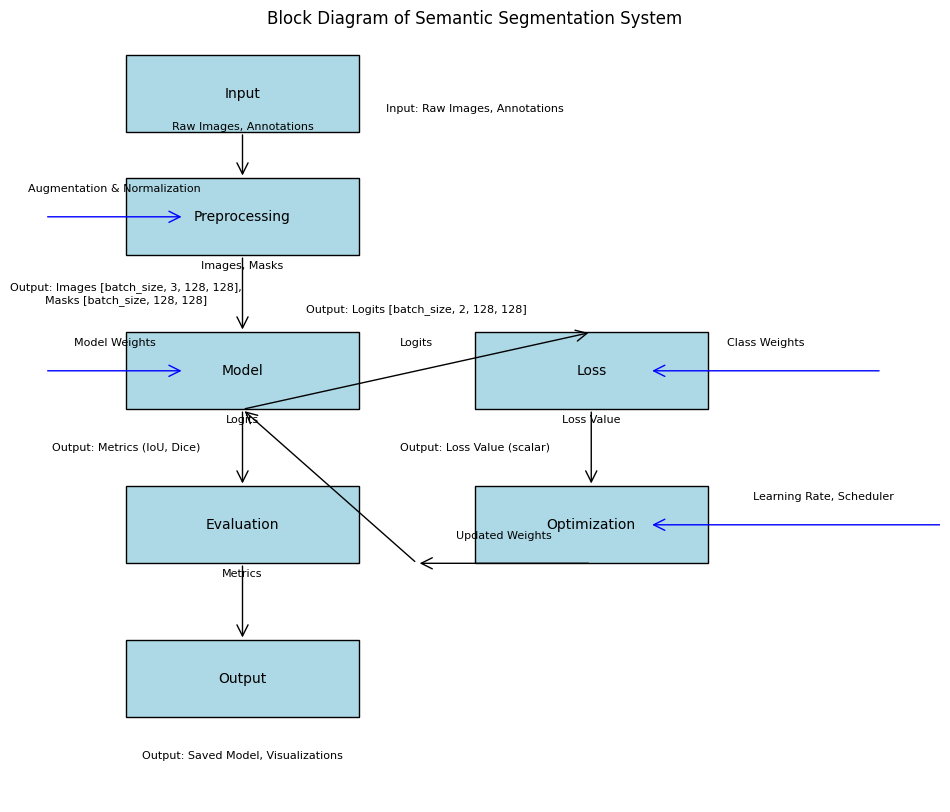

In [41]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyArrowPatch

# Create a figure and axis with increased height to accommodate more spacing
fig, ax = plt.subplots(figsize=(12, 10))  # Increased height from 8 to 10

# Define positions for each block (x, y coordinates) with increased vertical spacing
block_positions = {
    "Input": (0.2, 0.92),  # Adjusted y-coordinate
    "Preprocessing": (0.2, 0.76),  # Increased spacing (0.92 - 0.76 = 0.16)
    "Model": (0.2, 0.56),  # Increased spacing (0.76 - 0.56 = 0.20)
    "Loss": (0.5, 0.56),
    "Optimization": (0.5, 0.36),  # Increased spacing (0.56 - 0.36 = 0.20)
    "Evaluation": (0.2, 0.36),  # Increased spacing (0.56 - 0.36 = 0.20)
    "Output": (0.2, 0.16)  # Increased spacing (0.36 - 0.16 = 0.20)
}

# Define block dimensions
block_width = 0.2
block_height = 0.1

# Function to draw a block
def draw_block(ax, position, label, width, height):
    rect = patches.Rectangle(
        (position[0] - width/2, position[1] - height/2), width, height,
        linewidth=1, edgecolor='black', facecolor='lightblue'
    )
    ax.add_patch(rect)
    ax.text(position[0], position[1], label, ha='center', va='center', fontsize=10)

# Function to draw an arrow with adjusted label positioning
def draw_arrow(ax, start, end, label=None, color='black'):
    arrow = FancyArrowPatch(
        start, end, arrowstyle='->', mutation_scale=20, color=color
    )
    ax.add_patch(arrow)
    if label:
        mid_x = (start[0] + end[0]) / 2
        mid_y = (start[1] + end[1]) / 2
        # Adjust the offset to prevent overlap (increased from 0.02 to 0.03)
        ax.text(mid_x, mid_y + 0.03, label, ha='center', va='bottom', fontsize=8)

# Draw all blocks
for block, pos in block_positions.items():
    draw_block(ax, pos, block, block_width, block_height)

# Draw arrows for data flow with adjusted positions
draw_arrow(ax, (0.2, 0.87), (0.2, 0.81), "Raw Images, Annotations")
draw_arrow(ax, (0.2, 0.71), (0.2, 0.61), "Images, Masks")
draw_arrow(ax, (0.2, 0.51), (0.5, 0.61), "Logits")
draw_arrow(ax, (0.5, 0.51), (0.5, 0.41), "Loss Value")
draw_arrow(ax, (0.5, 0.31), (0.35, 0.31), "Updated Weights")
draw_arrow(ax, (0.35, 0.31), (0.2, 0.51), None)
draw_arrow(ax, (0.2, 0.51), (0.2, 0.41), "Logits")
draw_arrow(ax, (0.2, 0.31), (0.2, 0.21), "Metrics")

# Draw arrows for commands/parameters with adjusted positions
draw_arrow(ax, (0.03, 0.76), (0.15, 0.76), "Augmentation & Normalization", color='blue')
draw_arrow(ax, (0.03, 0.56), (0.15, 0.56), "Model Weights", color='blue')
draw_arrow(ax, (0.75, 0.56), (0.55, 0.56), "Class Weights", color='blue')
draw_arrow(ax, (0.85, 0.36), (0.55, 0.36), "Learning Rate, Scheduler", color='blue')

# Add labels for inputs/outputs with adjusted positions to avoid overlap
ax.text(0.4, 0.90, "Input: Raw Images, Annotations", ha='center', va='center', fontsize=8)
ax.text(0.1, 0.66, "Output: Images [batch_size, 3, 128, 128],\nMasks [batch_size, 128, 128]",
        ha='center', va='center', fontsize=8)  # Added newline to split the text
ax.text(0.35, 0.64, "Output: Logits [batch_size, 2, 128, 128]", ha='center', va='center', fontsize=8)
ax.text(0.4, 0.46, "Output: Loss Value (scalar)", ha='center', va='center', fontsize=8)
ax.text(0.1, 0.46, "Output: Metrics (IoU, Dice)", ha='center', va='center', fontsize=8)
ax.text(0.2, 0.06, "Output: Saved Model, Visualizations", ha='center', va='center', fontsize=8)

# Set axis limits and remove axes
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 1)
ax.axis('off')

# Add a title
plt.title("Block Diagram of Semantic Segmentation System", fontsize=12)

# Save the diagram as an image
plt.savefig("block_diagram.png", dpi=300, bbox_inches='tight')
plt.show()